# Modelagem de Tópicos

**Limpeza Preliminar**

Remove registros duplicados e entradas que não possuem resumo, pois a ausência de texto impede o cálculo probabilístico do LDA.

In [6]:
import pandas as pd

# 1. Carregar os dados originais
df = pd.read_csv('../dados/dados_lda.csv')

# Número de registros originais
registros_originais = len(df)

# 2. Remover registros duplicados
# Consideramos duplicatas registros que possuem o mesmo título e resumo
df = df.drop_duplicates(subset=['Title', 'Abstract'], keep='first')

# 3. Remover entradas onde o campo 'Abstract' está nulo (NaN)
df = df.dropna(subset=['Abstract'])

# 4. Limpeza de ruídos nos resumos
# Removemos espaços em branco extras e convertemos para string
df['Abstract'] = df['Abstract'].astype(str).str.strip()

# Filtrar placeholders comuns (avisos de que o resumo não está disponível)
placeholders = ["[No abstract available]", "No abstract available", "[No abstract available].", "None"]
df = df[~df['Abstract'].isin(placeholders)]

# Opcional: Remover resumos extremamente curtos (menos de 50 caracteres)
# Textos muito pequenos enviesam a probabilidade do LDA
df = df[df['Abstract'].str.len() > 50]

# 5. Salvar o resultado final
df.to_csv('../dados/dados_lda_limpo.csv', index=False)

print(f"Total de registros originais: {registros_originais}")
print(f"Total de registros limpos...: {len(df)}")

Total de registros originais: 16203
Total de registros limpos...: 16126


# Motor de Tópicos (LDA)

Cluster 1: research, use, medical, care, artificial, intelligence, study, health, healthcare, ai
Cluster 2: machine, results, clinical, using, models, study, data, risk, model, patients
Cluster 3: covid, dataset, performance, classification, models, using, machine, learning, accuracy, model
Cluster 4: proposed, iot, real, time, systems, medical, based, learning, healthcare, data
Cluster 5: machine, treatment, model, decision, data, learning, patient, models, healthcare, clinical


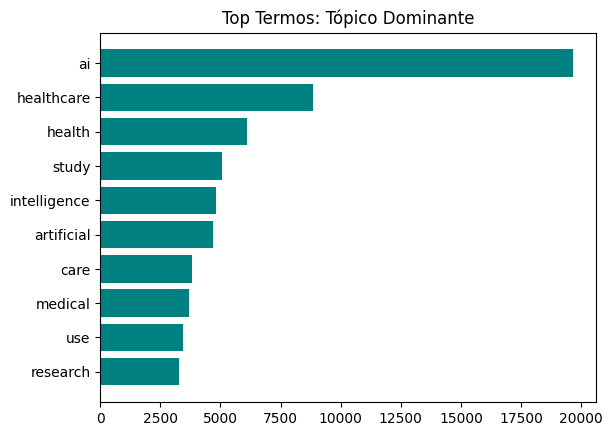

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

# Carregamento dos dados exportados da base bibliométrica
# Certifique-se de que o arquivo 'dados_ciencia.csv' está no diretório
df = pd.read_csv('../dados/dados_lda_limpo.csv')

# 1. Vetorização: Transformando palavras em matrizes numéricas
# Removemos termos comuns (stopwords) que não agregam valor semântico
vectorizer = CountVectorizer(stop_words='english', max_features=2000)
matriz_termos = vectorizer.fit_transform(df['Abstract'].dropna())

# 2. Configuração do Modelo LDA
# Definimos o número de tópicos (K). Em estudos reais, testamos vários valores.
numero_de_topicos = 5
lda = LatentDirichletAllocation(n_components=numero_de_topicos, random_state=42)
lda.fit(matriz_termos)

# 3. Extração dos termos principais de cada cluster
palavras = vectorizer.get_feature_names_out()
for i, topico in enumerate(lda.components_):
    top_indices = topico.argsort()[-10:]
    termos = [palavras[idx] for idx in top_indices]
    print(f"Cluster {i+1}: {', '.join(termos)}")

# 4. Visualização da Importância (Salvando gráfico)
# Exemplo para o primeiro tópico identificado
importancia = lda.components_[0][lda.components_[0].argsort()[-10:]]
termos_grafico = [palavras[idx] for idx in lda.components_[0].argsort()[-10:]]

plt.barh(termos_grafico, importancia, color='teal')
plt.title('Top Termos: Tópico Dominante')
plt.savefig('analise_topico.png')

# Interpretação dos Resultados


**Cluster 1**: Fundamentos e Governança da IA na Saúde

**words**: research, use, medical, care, artificial, intelligence, study, health, healthcare, ai

Este grupo reúne termos genéricos e conceituais. Ele representa a base teórica e as discussões amplas sobre o impacto da inteligência artificial no setor médico. É o tópico que geralmente aparece em artigos de revisão, diretrizes de políticas de saúde e estudos que avaliam o panorama geral da tecnologia no cuidado ao paciente.

**Rótulo Sugerido:** Paradigmas e Fundamentos da IA em Sistemas de Saúde.

---

**Cluster 2:** Predição de Risco e Modelagem Clínica

**words**: machine, results, clinical, using, models, study, data, risk, model, patients

Aqui o foco sai do campo teórico e entra na aplicação direta. As palavras indicam um esforço em usar modelos para calcular probabilidades de eventos adversos ou riscos em pacientes. É o núcleo da medicina preditiva, onde o objetivo é antecipar diagnósticos ou complicações com base em dados históricos.

**Rótulo Sugerido:** Modelagem Preditiva de Risco e Análise de Desfechos Clínicos.

---

**Cluster 3:** Diagnóstico Computacional e Resposta à COVID-19

**words:** covid, dataset, performance, classification, models, using, machine, learning, accuracy, model

Este tópico é muito específico e revela um "pico" temporal na literatura recente. Ele foca na performance técnica de algoritmos de classificação, com forte influência de bases de dados geradas durante a pandemia. Aqui o rigor está na acurácia e na validação técnica dos modelos.

**Rótulo Sugerido:** Classificação Diagnóstica e Algoritmos de Alta Performance (Contexto Pandêmico).

---

**Cluster 4:** Monitoramento em Tempo Real e IoMT (Internet das Coisas)

**words:** proposed, iot, real, time, systems, medical, based, learning, healthcare, data

A presença de termos como "IoT" e "real time" sugere uma infraestrutura tecnológica baseada em sensores e dispositivos conectados. Este cluster não trata apenas do software, mas do hardware e dos sistemas propostos para monitorar pacientes fora do ambiente hospitalar tradicional.

**Rótulo Sugerido:** Infraestrutura de Monitoramento Remoto e Sistemas de Saúde Inteligentes.

---

**Cluster 5:** Apoio à Decisão e Personalização do Tratamento

**words:** machine, treatment, model, decision, data, learning, patient, models, healthcare, clinical

Enquanto o Cluster 2 foca no risco, o Cluster 5 foca na ação. Os termos indicam o uso de modelos para auxiliar o médico na escolha do melhor tratamento. É a área de Sistemas de Apoio à Decisão Clínica (CDSS), onde a máquina atua como um braço direito na recomendação de condutas terapêuticas.

**Rótulo Sugerido:** Sistemas de Suporte à Decisão Clínica e Terapêutica Personalizada.

# Detecção de Sinais Fracos e Tendências

Principais Sinais Fracos (Temas Emergentes para sua RSL):
                                   palavra_chave  frequencia_passada  \
1636                                     chatgpt                   0   
19532                      large language models                   0   
22287                       large language model                   0   
7763                               generative ai                   0   
2783                            ai in healthcare                   2   
18293                          patient education                   0   
180           generative artificial intelligence                   0   
9342                       healthcare technology                   1   
9464   explainable artificial intelligence (xai)                   2   
12379             machine learning in healthcare                   2   
1960       artificial intelligence in healthcare                   1   
4725                                    attitude                   1   
9513  

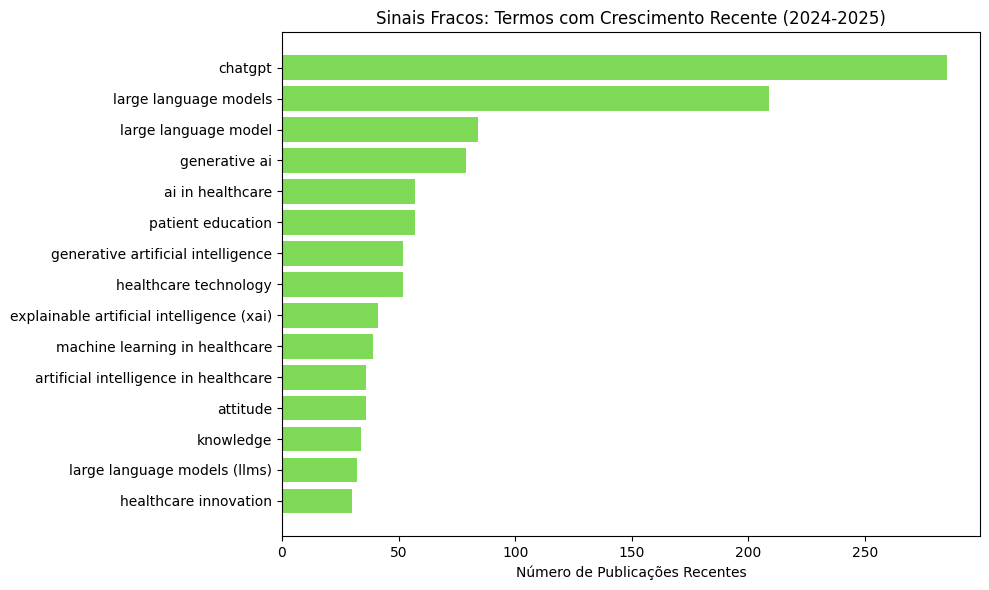

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Carregamento dos dados
# Certifique-se de que o arquivo está na mesma pasta do seu script
df = pd.read_csv('../dados/dados_lda_limpo.csv')

# 1. Definição dos Períodos para Análise de Evolução
# Comparamos o início da década com os anos mais recentes
periodo_passado = [2021, 2022]
periodo_recente = [2024, 2025]

def extrair_frequencia_keywords(dataframe):
    lista_kws = []
    for linha in dataframe['Author Keywords'].dropna():
        # Limpamos espaços e padronizamos para minúsculas
        termos = [t.strip().lower() for t in linha.split(';')]
        lista_kws.extend(termos)
    return Counter(lista_kws)

# Extração das contagens por período
contagem_passada = extrair_frequencia_keywords(df[df['Year'].isin(periodo_passado)])
contagem_recente = extrair_frequencia_keywords(df[df['Year'].isin(periodo_recente)])

# 2. Cálculo do Crescimento e Mapeamento de Sinais
todas_as_palavras = set(list(contagem_passada.keys()) + list(contagem_recente.keys()))
dados_evolucao = []

for termo in todas_as_palavras:
    freq_passada = contagem_passada.get(termo, 0)
    freq_recente = contagem_recente.get(termo, 0)
    crescimento = freq_recente - freq_passada
    
    dados_evolucao.append({
        'palavra_chave': termo,
        'frequencia_passada': freq_passada,
        'frequencia_recente': freq_recente,
        'crescimento_absoluto': crescimento
    })

df_evolucao = pd.DataFrame(dados_evolucao)

# 3. Definição da Variável sinal_fraco
# Aqui definimos como sinal fraco os termos que tinham menos de 3 ocorrências 
# no passado e que agora aparecem pelo menos 5 vezes.
sinal_fraco = df_evolucao[
    (df_evolucao['frequencia_passada'] < 3) & 
    (df_evolucao['frequencia_recente'] >= 5)
].sort_values(by='frequencia_recente', ascending=False)

# 4. Exibição dos resultados principais
print("Principais Sinais Fracos (Temas Emergentes para sua RSL):")
print(sinal_fraco[['palavra_chave', 'frequencia_passada', 'frequencia_recente']].head(15))

# 5. Visualização Gráfica
plt.figure(figsize=(10, 6))
top_sinais = sinal_fraco.head(15)
plt.barh(top_sinais['palavra_chave'], top_sinais['frequencia_recente'], color='#7ed957')
plt.title('Sinais Fracos: Termos com Crescimento Recente (2024-2025)')
plt.xlabel('Número de Publicações Recentes')
plt.gca().invert_yaxis()  # Inverte para o maior aparecer no topo
plt.tight_layout()
plt.savefig('analise_sinais_emergentes.png')

print("\nGráfico gerado com sucesso: analise_sinais_emergentes.png")